# Depth comparison -- circuit depth sweep (hybrid quantum CNN)

A focused, depth-only view: overlays the training curves of all four Phase 3 depth-sweep configs (`n_qlayers` in {1, 2, 3, 4}, `n_qubits` fixed at 4) on the same axes, so their convergence behavior -- not just final accuracy -- can be compared directly. `depth_2` (`n_qlayers=2`) is the project baseline used everywhere else in this dissertation.

Uses the existing Phase 3 `results/ablation/depth_*/metrics.csv` results (`training_seed=42`, `data_seed=42` throughout) -- no retraining.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.utils.plotting import plot_comparison

print('Imports OK')
print(f'Project root: {project_root}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation


## Configuration

In [2]:
def load_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)

DEPTH_RUNS = [
    {
        'label': f'depth_{n}',
        'n_qlayers': n,
        'config': project_root / 'configs' / 'ablation' / f'depth_{n}.yaml',
        'results_dir': project_root / 'results' / 'ablation' / f'depth_{n}',
    }
    for n in [1, 2, 3, 4]
]

for spec in DEPTH_RUNS:
    print(f"{spec['label']}: {spec['config']}")

depth_1: D:\Dissertation\qcnn-dissertation\configs\ablation\depth_1.yaml
depth_2: D:\Dissertation\qcnn-dissertation\configs\ablation\depth_2.yaml
depth_3: D:\Dissertation\qcnn-dissertation\configs\ablation\depth_3.yaml
depth_4: D:\Dissertation\qcnn-dissertation\configs\ablation\depth_4.yaml


## 1. Configuration summary

In [3]:
rows = []
for spec in DEPTH_RUNS:
    cfg = load_config(spec['config'])
    rows.append({
        'run': spec['label'],
        'n_qubits': cfg['model'].get('n_qubits'),
        'n_qlayers': cfg['model'].get('n_qlayers'),
        'epochs': cfg['training'].get('epochs'),
        'data_seed': cfg.get('data_seed'),
        'training_seed': cfg.get('training_seed'),
    })

config_summary_df = pd.DataFrame(rows)
display(config_summary_df)

,run,n_qubits,n_qlayers,epochs,data_seed,training_seed
0,depth_1,4,1,15,42,42
1,depth_2,4,2,15,42,42
2,depth_3,4,3,15,42,42
3,depth_4,4,4,15,42,42


## 2. Final-epoch metrics

In [4]:
final_rows = []
for spec in DEPTH_RUNS:
    df = pd.read_csv(spec['results_dir'] / 'metrics.csv')
    final = df.iloc[-1]
    final_rows.append({
        'run': spec['label'],
        'n_qlayers': spec['n_qlayers'],
        'accuracy': final['accuracy'],
        'f1_macro': final['f1_macro'],
        'precision_macro': final['precision_macro'],
        'recall_macro': final['recall_macro'],
        'parameter_count': final['parameter_count'],
        'epoch_time_sec': final['epoch_time_sec'],
    })

final_df = pd.DataFrame(final_rows)
display(final_df)

,run,n_qlayers,accuracy,f1_macro,precision_macro,recall_macro,parameter_count,epoch_time_sec
0,depth_1,1,0.993333,0.993333,0.993333,0.993333,2295.0,0.601542
1,depth_2,2,0.976667,0.976814,0.978193,0.976667,2299.0,0.715185
2,depth_3,3,0.986667,0.986665,0.986890,0.986667,2303.0,0.802377
3,depth_4,4,0.990000,0.990000,0.990097,0.990000,2307.0,0.856793


## 3. Training loss vs epoch

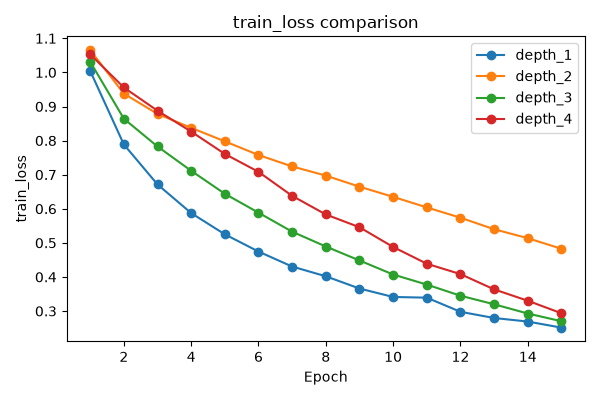

In [5]:
csv_paths = {spec['label']: spec['results_dir'] / 'metrics.csv' for spec in DEPTH_RUNS}

train_loss_fig_path = project_root / 'figures' / 'depth_comparison_train_loss.png'
plot_comparison(csv_paths, 'train_loss', train_loss_fig_path)
display(Image(filename=str(train_loss_fig_path)))

## 4. Test loss vs epoch

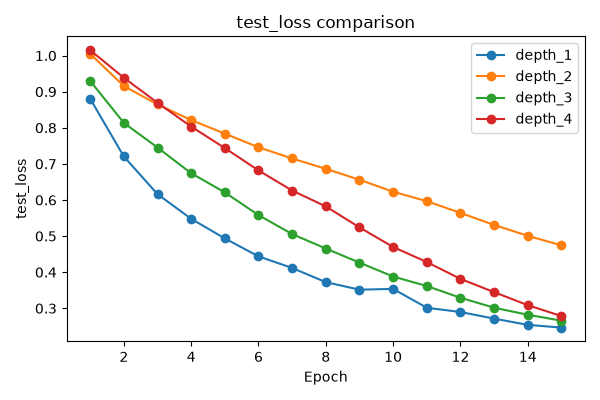

In [6]:
test_loss_fig_path = project_root / 'figures' / 'depth_comparison_test_loss.png'
plot_comparison(csv_paths, 'test_loss', test_loss_fig_path)
display(Image(filename=str(test_loss_fig_path)))

## 5. Accuracy vs epoch

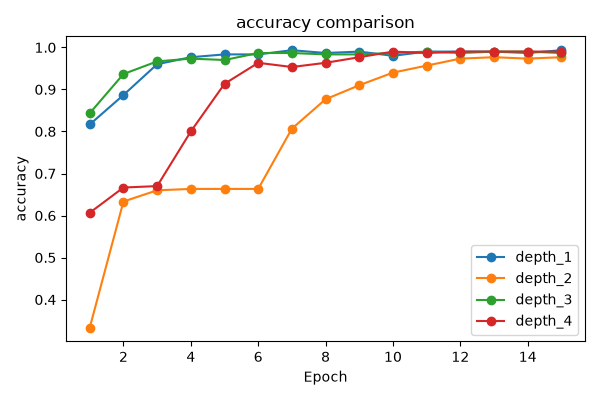

In [7]:
acc_fig_path = project_root / 'figures' / 'depth_comparison_accuracy.png'
plot_comparison(csv_paths, 'accuracy', acc_fig_path)
display(Image(filename=str(acc_fig_path)))

## Interpretation notes

All four depths converge smoothly with no divergence or instability at `training_seed=42` -- the non-monotonic final accuracy across depth (see `figures/ablation_depth.png` and the Phase 3 notebook) is a difference in *where* each depth's single seed landed, not a difference in *how* training behaved. `depth_2` is the configuration used everywhere else in this dissertation; `notebooks/exploratory_multiseed.ipynb` checks whether its Phase 3 ranking against `depth_1` holds up across multiple seeds -- it does, and more importantly `depth_1` (not `depth_2`) is the one that shows real instability across seeds (see that notebook's Section 5).